In [1]:
import numpy as np
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
from model_augmentation_jax import GeneralNonlinearSystem, StaticLFRAugmentation
from model_augmentation_jax.utils import NRMSE_loss, compute_normalization_constants


jax.config.update('jax_platform_name', 'cpu')
if not jax.config.jax_enable_x64:
    jax.config.update("jax_enable_x64", True)  # Enable 64-bit computations

Now, we show how to implement the dynamics of an arbitrary baseline model by using the `GeneralNonlinearSystem` class.

In [2]:
# create nonlinear baseline model
class nonlinear_baseline_model(GeneralNonlinearSystem):
    def __init__(self, init_params, tune_params):
        # for nonlinear baseline models, there is an option to co-estimate the physical parameters with the
        # learning-based ones
        super().__init__(nx=2, ny=1, nu=1, params=init_params, tune_params=tune_params)

    def f(self, x, u, params):
        # with nonlinear abseline models, the state transition function and output maps must be implemented manually
        x1_plus = params[0] * x[0] + params[1] * x[1] + params[2] * u[0]
        x2_plus = -params[3] * x[0] + params[4] * x[1] - params[5] * x[0]**3
        return jnp.array([x1_plus, x2_plus])

    def h(self, x, u, params):
        return x[0:1]

We use the same data-generating system, then initialize the baseline model by calling the defined `nonlinear_baseline_model` class. For simulating the baseline model, we can use the same syntax as before.

In [ ]:
# Generate or load data
np.random.seed(0)
U = np.random.normal(size=10_000) # Input sequence
x = [0, 0] # Initial state
ylist = [] # Output sequence
for uk in U:
    ylist.append(x[0] + np.random.normal(loc=0., scale=0.01))  # Compute output
    x = 0.9 * x[0] + 0.1 * x[1] + 0.1 * uk + 0.02 * x[0] * x[1], \
       -0.2 * x[0] + 0.95 * x[1] + 0.05 * uk - 0.1 * x[0]**3 # Advance state

# Split dataset
Y = np.array(ylist)
Y_train = Y[:9000]
Y_test = Y[9000:]
U_train = U[:9000]
U_test = U[9000:]

# create baseline model (with approximate params)
init_baseline_params = np.array([0.8, 0.15, 0.12, 0.18, 0.9, 0.08])
fp_model = nonlinear_baseline_model(init_params=init_baseline_params, tune_params=True)  # also indicate whether to tune the baseline parameters

# simulate baseline model to approximate constants for normalization
Yhat_train_base, Xhat_train_base = fp_model.simulate(U_train)  # starts from x0 = 0
norm = compute_normalization_constants(U_train, Y_train, Xhat_train_base)

For augmentation, we use the same hyperparameters as before. But now, we show how one can set the $D_\mathrm{zw}$ matrix lower triangular (the default is $D_\mathrm{zw}\equiv 0$).

In [4]:
model = StaticLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2,
                                  norm_dict=norm, Dzw_structure="lower")  # just add the argument: Dzw_structure="lower"

# set training options
model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=50)

Since now, we also tune the baseline parameters, we can regularize the deviation from the initial values to avoid reaching unrealistic domains. The regularization options can be simply chosen by calling the `set_regularization_terms` method.

In [5]:
model.set_regularization_terms(rho_base=1e-3)

Deviations of the physical parameters from their nominal values are penalized with coefficient: alpha=0.001


Training and testing can be started as before:

In [ ]:
# train the model
model.fit(Y_train, U_train)

In [7]:
print(f"Model training finished in {model.t_solve} seconds.")

Model training finished in 4.795905590057373 seconds.


Note that this is a quite simple example, and hence, no performance gain is visible when providing a more accurate, nonlinear baseline model. However, in real-world applications, this is a really useful feature.

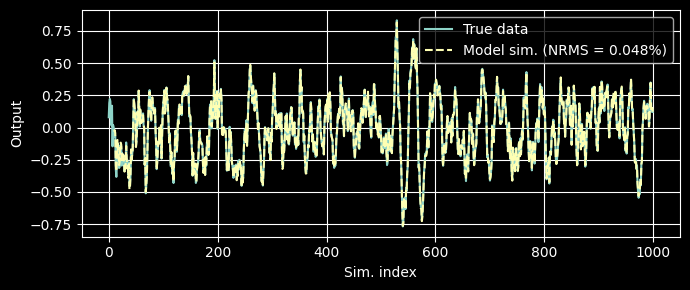

In [8]:
# estimate initial state based on first 10 samples of the test data
x0_test = model.learn_x0(U_test[:10], Y_test[:10], verbosity=False)

# simulate model
Yhat_test, _ = model.simulate(U_test, X0=x0_test)

nrmse = NRMSE_loss(Yhat_test[10:], Y_test[10:])  # only consider the part that was not used in state estimation

# visualize model output
sim_idx = np.arange(U_test.shape[0])
plt.figure(figsize=(7,3), layout="tight")
plt.plot(sim_idx, Y_test, label="True data")
plt.plot(sim_idx[10:], Yhat_test[10:], '--', label=f"Model sim. (NRMS = {nrmse:.2}%)")
plt.legend()
plt.grid()
plt.xlabel("Sim. index")
plt.ylabel("Output")
plt.show()